# shapiq — Shapley Interactions

[`shapiq`](https://github.com/mmschlk/shapiq) (NeurIPS 2024) extends classical SHAP by computing **any-order Shapley interaction values**, quantifying not just how much each feature contributes individually but also how features *synergise* or *suppress* each other.

## Key concepts

| Index | Description |
|---|---|
| **SV** | Classic Shapley Values — first-order, one attribution per feature |
| **k-SII** | k-Shapley Interaction Index — decomposes each feature's attribution into a main effect plus interaction terms up to order *k*; SV is recovered at order 1 |
| **FSII / FBII** | Faithful / Faith-Based Interaction variants |

## This notebook

For every dataset × model combination we compare two shapiq explainers and record wall-clock time:

| Method | Index | Order | Notes |
|---|---|---|---|
| **KernelSHAP** | `SV` | 1 | Kernel regression approximation of first-order Shapley values; identical to the classical KernelSHAP algorithm |
| **TabularExplainer k-SII** | `k-SII` | 4 | Full Shapley interaction values up to 4th order; uses SPEX/SVARM internally; exact when `budget ≥ 2ⁿ` |

Budget is set to `2^n` (exact) for datasets with ≤ 8 features and capped at 512 (approximation) otherwise.  
Each explainer is evaluated on 3 held-out instances; per-sample runtimes are reported.  
Visualisations: runtime bar chart, waterfall plot (SV), waterfall + force plot (k-SII).

In [2]:
from Models.load_and_train import TrainingConfig

# Load and train all dataset × model combinations (sklearn models only)
all_combi_configs = TrainingConfig.get_all_configs(pytorch=False)
all_trained_models = [config.train(verbose=True) for config in all_combi_configs]

print("All models trained successfully!")
print(f"Total number of trained models: {len(all_trained_models)}")

Trained random_forest_regressor on california_housing
Trained random_forest_regressor on ames_housing
Trained random_forest_regressor on covertype
All models trained successfully!
Total number of trained models: 3



=== California Housing | random_forest_regressor | n=8 (exact) ===
  KernelSHAP (index='SV', max_order=1) ...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

  k-SII (index='k-SII', max_order=4) ...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

  KernelSHAP (SV): 1.451s | k-SII: 1.226s (3 samples, 0.484s vs 0.409s per sample)


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

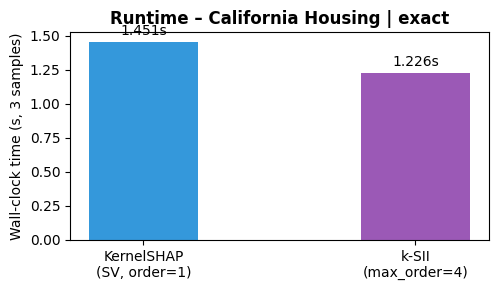

  KernelSHAP (SV) waterfall – California Housing (sample 0):


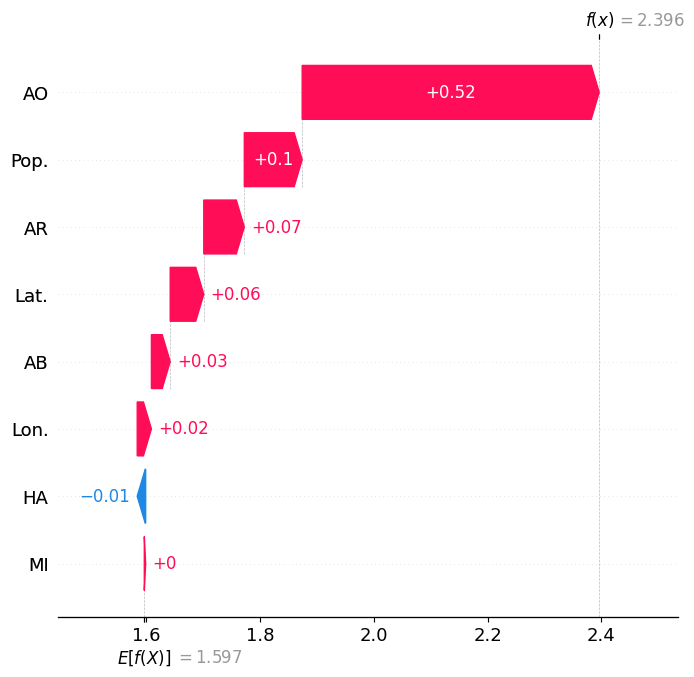

  k-SII waterfall – California Housing (sample 0):


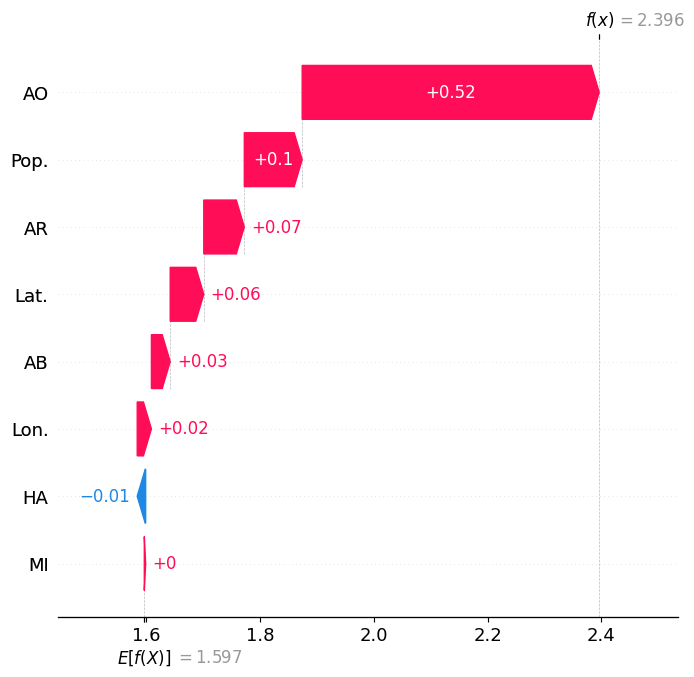

  k-SII force plot – California Housing (sample 0):


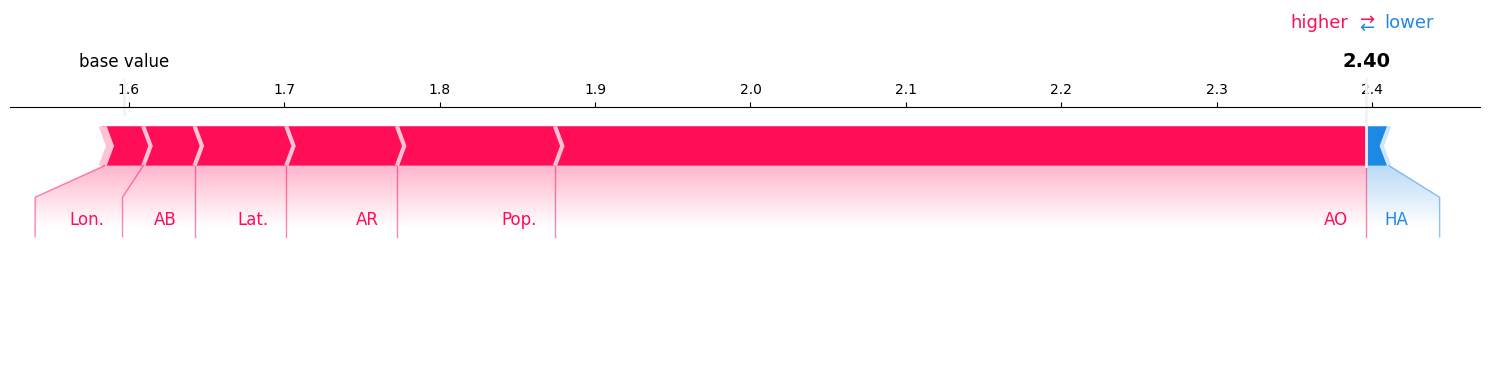


=== Ames Housing | random_forest_regressor | n=79 (approx, budget=512) ===
  KernelSHAP (index='SV', max_order=1) ...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

  k-SII (index='k-SII', max_order=4) ...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

  KernelSHAP (SV): 1.623s | k-SII: 1.623s (3 samples, 0.541s vs 0.541s per sample)


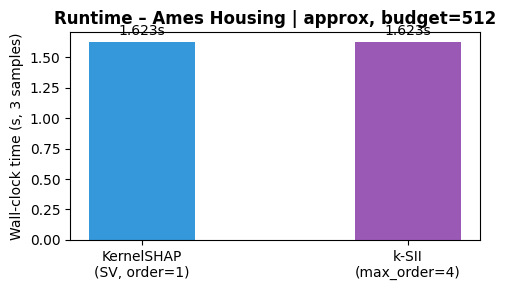

  KernelSHAP (SV) waterfall – Ames Housing (sample 0):


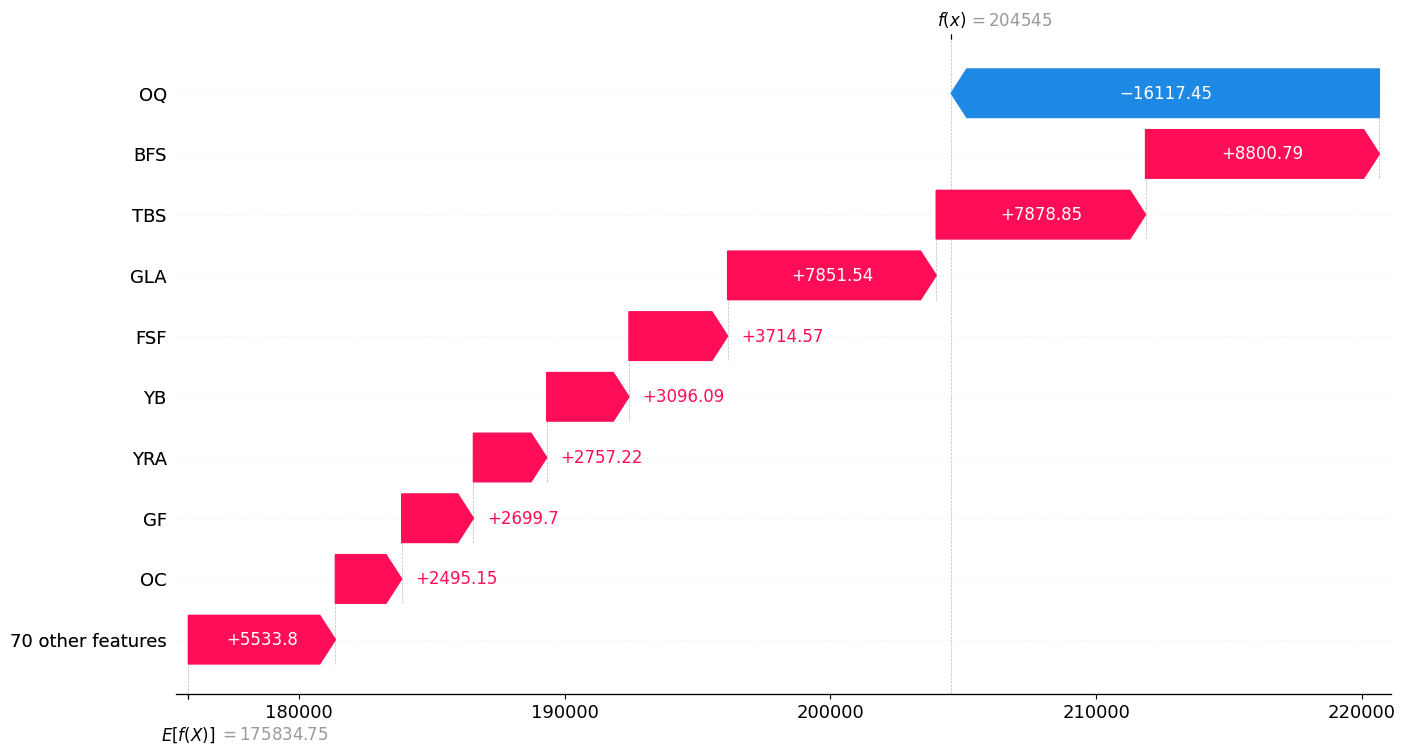

  k-SII waterfall – Ames Housing (sample 0):


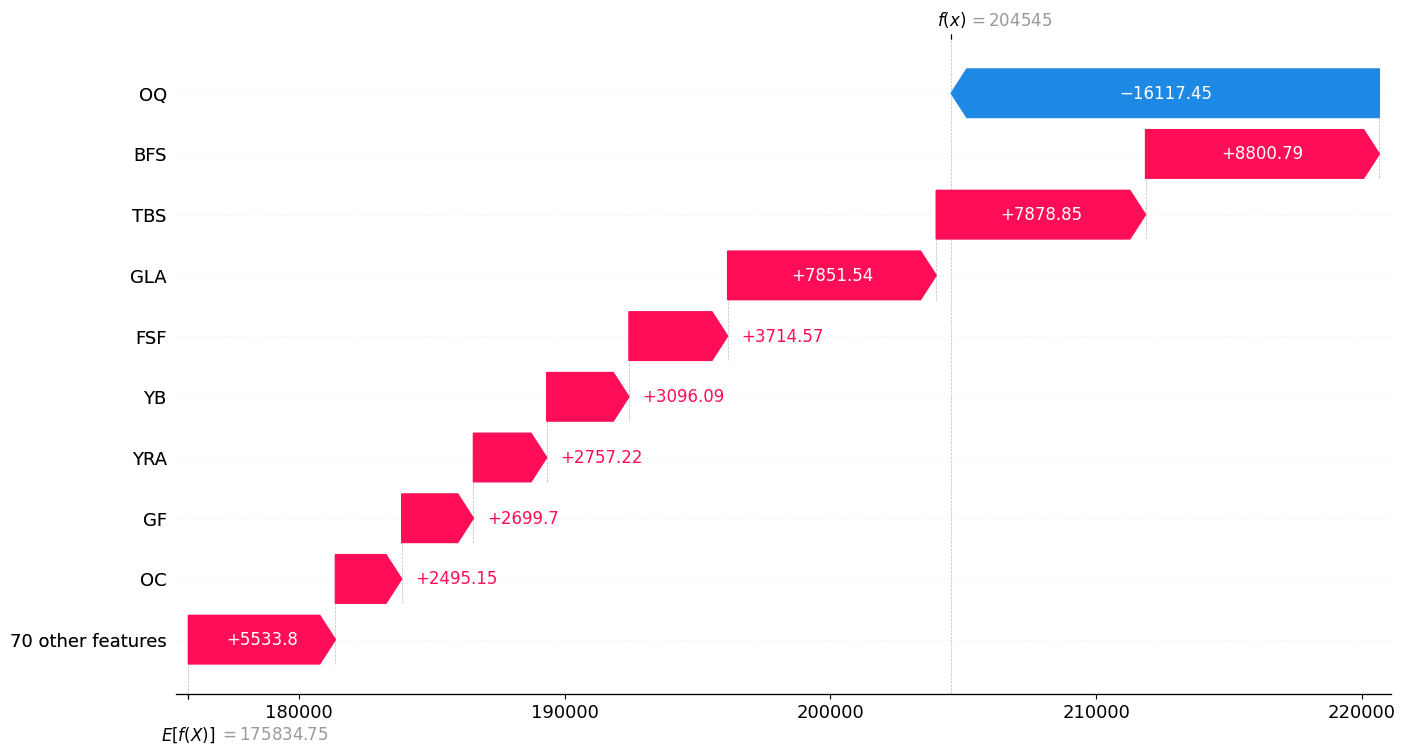

  k-SII force plot – Ames Housing (sample 0):


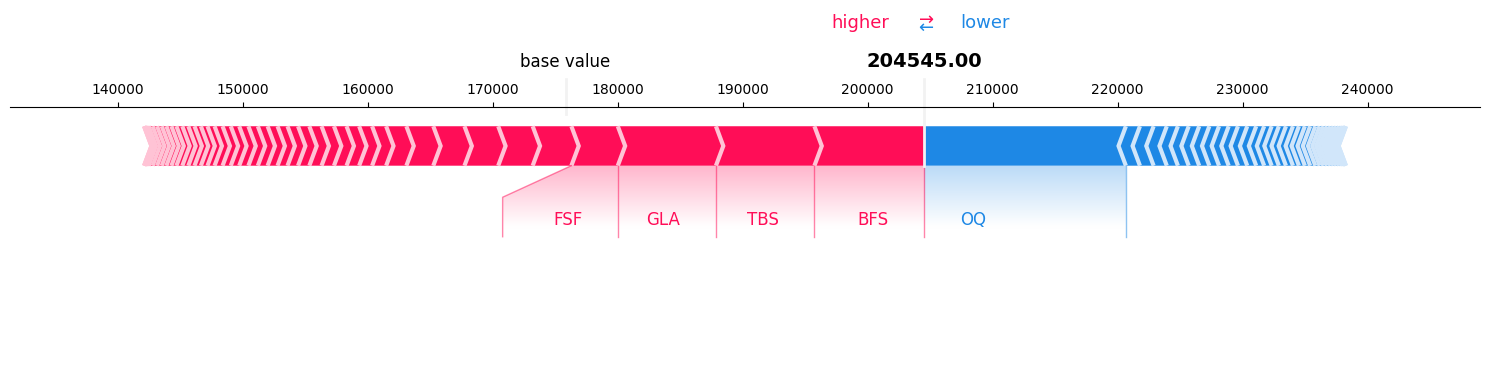


=== Forest Covertype | random_forest_regressor | n=54 (approx, budget=512) ===
  KernelSHAP (index='SV', max_order=1) ...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

  k-SII (index='k-SII', max_order=4) ...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/shapiq/explainer/validation.py:92: UserWarning: Mismatch between max_order=1 and index=k-SII. k-SII generalizes 'SV'. Setting index to 'SV'.
  validated_index = validate_index(index, max_order)
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691

  KernelSHAP (SV): 1.814s | k-SII: 1.862s (3 samples, 0.605s vs 0.621s per sample)


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


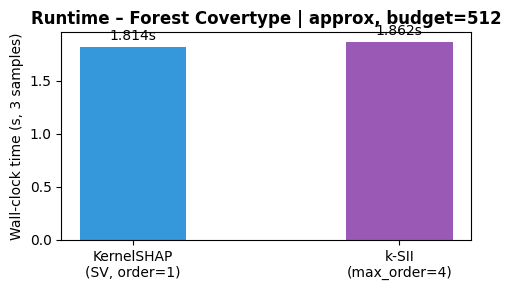

  KernelSHAP (SV) waterfall – Forest Covertype (sample 0):


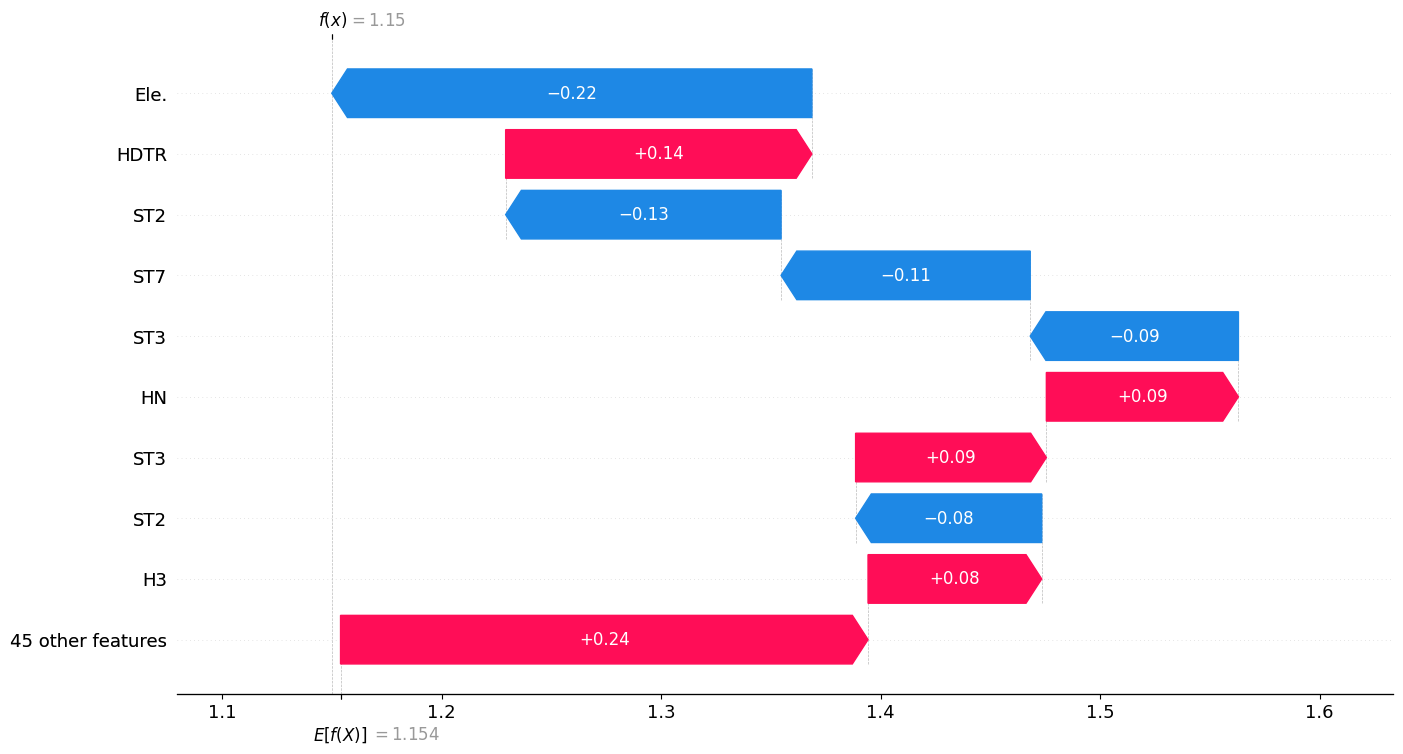

  k-SII waterfall – Forest Covertype (sample 0):


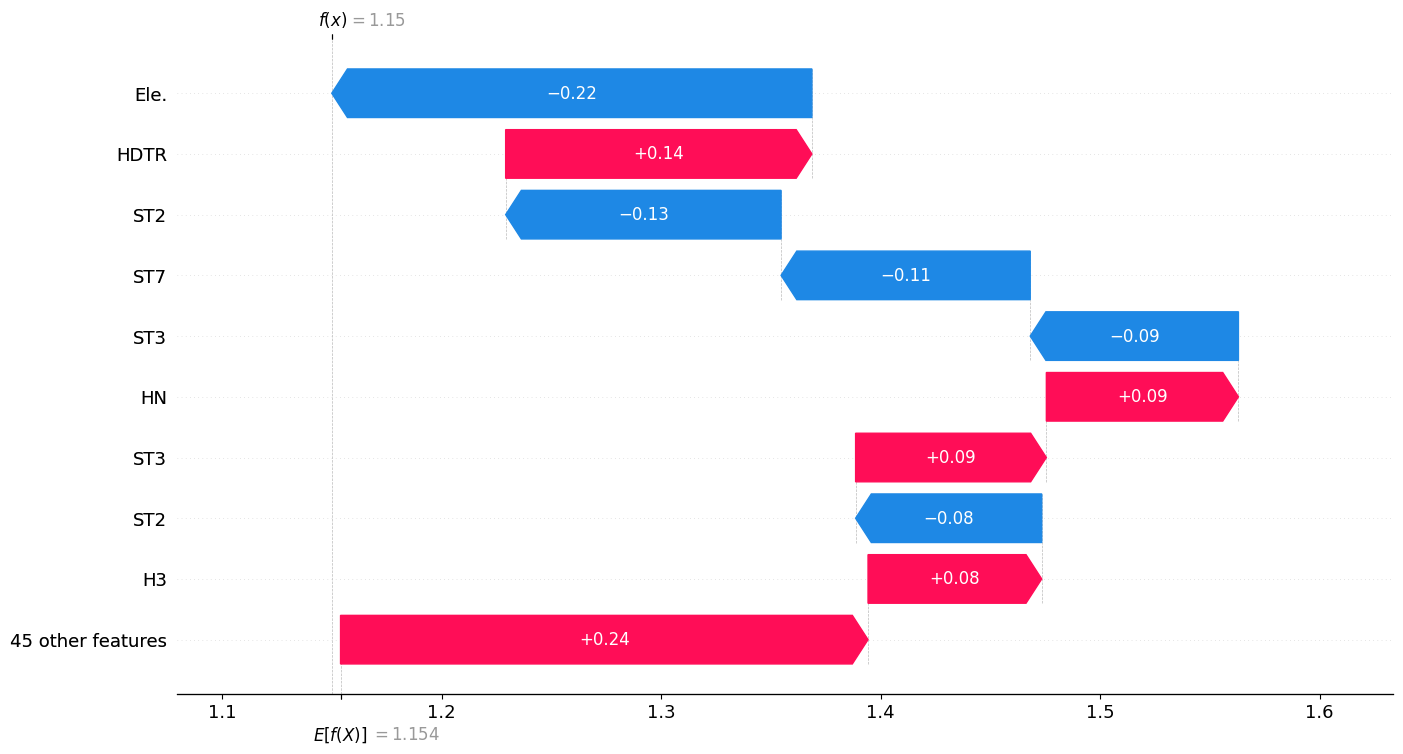

  k-SII force plot – Forest Covertype (sample 0):


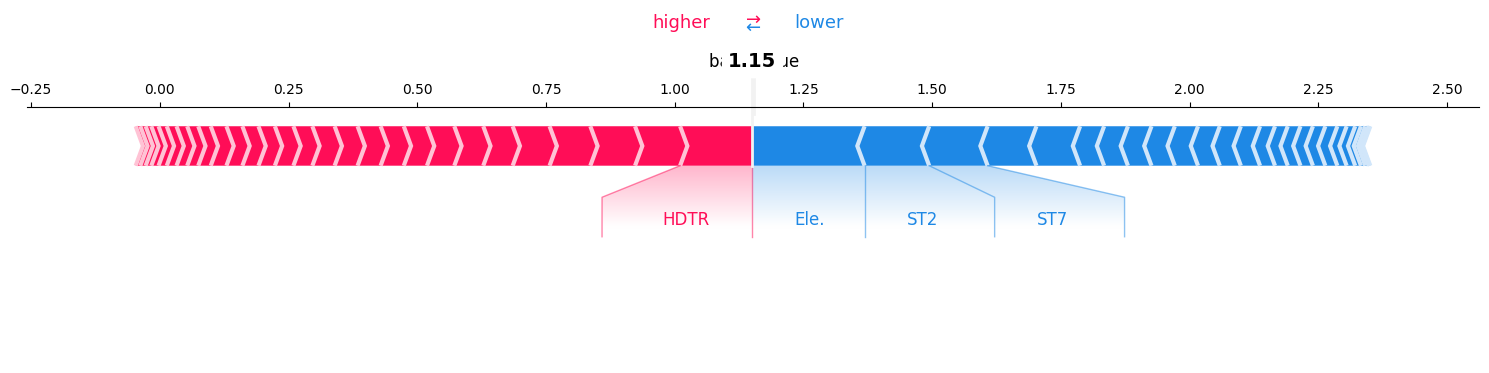

In [4]:
import shapiq
import time
import numpy as np
import matplotlib.pyplot as plt

N_BACKGROUND = 100   # size of marginal-imputer reference distribution
N_EVAL = 3           # instances to explain (kept small: k-SII is ~6s/sample on Ames Housing)

for config, model in zip(all_combi_configs, all_trained_models):
    data = config.dataset.load_dataset()
    X = data["X"]
    feature_names = np.array(data["feature_names"])
    n_features = len(feature_names)

    X_np = X.values if hasattr(X, "values") else np.array(X)
    X_background = X_np[:N_BACKGROUND]
    X_eval = X_np[N_BACKGROUND : N_BACKGROUND + N_EVAL]

    # Use exact budget when feasible (n ≤ 8), otherwise cap at 512
    exact_budget = 2**n_features
    budget = exact_budget if exact_budget <= 256 else 512
    mode = "exact" if exact_budget <= 256 else f"approx, budget={budget}"

    print(f"\n=== {data['name']} | {config.model.value} | n={n_features} ({mode}) ===")

    # ── KernelSHAP: SV index, first-order Shapley values ─────────────────────
    print("  KernelSHAP (index='SV', max_order=1) ...")
    sv_explainer = shapiq.TabularExplainer(
        model=model.predict,
        data=X_background,
        index="SV",
        max_order=1,
        random_state=42,
    )
    t0 = time.time()
    sv_ivs = [sv_explainer.explain(x, budget=budget) for x in X_eval]
    sv_duration = time.time() - t0

    # ── k-SII: Shapley interactions up to order 4 ─────────────────────────────
    print("  k-SII (index='k-SII', max_order=4) ...")
    ksii_explainer = shapiq.TabularExplainer(
        model=model.predict,
        data=X_background,
        index="k-SII",
        max_order=1,
        random_state=42,
    )
    t0 = time.time()
    ksii_ivs = [ksii_explainer.explain(x, budget=budget) for x in X_eval]
    ksii_duration = time.time() - t0

    print(
        f"  KernelSHAP (SV): {sv_duration:.3f}s | k-SII: {ksii_duration:.3f}s "
        f"({N_EVAL} samples, {sv_duration/N_EVAL:.3f}s vs {ksii_duration/N_EVAL:.3f}s per sample)"
    )

    # ── Runtime bar chart ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 3))
    labels = ["KernelSHAP\n(SV, order=1)", "k-SII\n(max_order=4)"]
    durations = [sv_duration, ksii_duration]
    bars = ax.bar(labels, durations, color=["#3498db", "#9b59b6"], width=0.4)
    for bar, dur in zip(bars, durations):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(durations) * 0.02,
            f"{dur:.3f}s",
            ha="center", va="bottom", fontsize=10,
        )
    ax.set_ylabel(f"Wall-clock time (s, {N_EVAL} samples)")
    ax.set_title(f"Runtime – {data['name']} | {mode}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── KernelSHAP waterfall – sample 0 ──────────────────────────────────────
    print(f"  KernelSHAP (SV) waterfall – {data['name']} (sample 0):")
    sv_ivs[0].plot_waterfall(feature_names=feature_names, show=True)

    # ── k-SII waterfall – sample 0 ───────────────────────────────────────────
    print(f"  k-SII waterfall – {data['name']} (sample 0):")
    ksii_ivs[0].plot_waterfall(feature_names=feature_names, show=True)

    # ── k-SII force plot – sample 0 (highlights pairwise interactions) ───────
    print(f"  k-SII force plot – {data['name']} (sample 0):")
    ksii_ivs[0].plot_force(feature_names=feature_names, show=True)